In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split,cross_val_score, KFold ,GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import numpy as np


In [2]:
#Load the dataset
DATA_DIR = '../data'

data = pd.read_csv(os.path.join(DATA_DIR,'processed' ,'sales_cleaned.csv'), parse_dates=['Date'])

data

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [3]:
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day
data['dayofweek'] = data['Date'].dt.dayofweek
data['is_weekend'] = data['dayofweek'].isin([5, 6]).astype(int)
holidays_and_sales = ['01-01', '02-14', '03-08', '04-30', '05-01', '09-02', '10-20', '11-11', '12-12', '12-24']
data['is_holiday'] = data['Date'].dt.strftime('%m-%d').isin(holidays_and_sales).astype(int)
data['dayofyear'] = data['Date'].dt.dayofyear
data['dayofyearsin'] = np.sin(2 * np.pi * data['dayofyear'] / 365.25)
data['dayofyearcos'] = np.cos(2 * np.pi * data['dayofyear'] / 365.25)
data['weekofyear'] = data['Date'].dt.isocalendar().week.astype(int)
data['sin_1'] = np.sin(2 * np.pi * data['dayofyear'] / 365.25)
data['cos_1'] = np.cos(2 * np.pi * data['dayofyear'] / 365.25)
data['sin_2'] = np.sin(2 * np.pi * data['dayofyear'] / (365.25/2))
data['cos_2'] = np.cos(2 * np.pi * data['dayofyear'] / (365.25/2))
data

,Date,Revenue,COGS,year,month,day,dayofweek,is_weekend,is_holiday,dayofyear,dayofyearsin,dayofyearcos,weekofyear,sin_1,cos_1,sin_2,cos_2
0,2012-07-04,5123547.94,3982991.19,2012,7,4,2,0,0,186,-0.058026,-0.998315,27,-0.058026,-0.998315,0.115856,0.993266
1,2012-07-05,2751773.45,2150580.23,2012,7,5,3,0,0,187,-0.075190,-0.997169,27,-0.075190,-0.997169,0.149953,0.988693
2,2012-07-06,3054029.42,2517632.84,2012,7,6,4,0,0,188,-0.092331,-0.995728,27,-0.092331,-0.995728,0.183874,0.982950
3,2012-07-07,2667930.94,2108246.62,2012,7,7,5,1,0,189,-0.109446,-0.993993,27,-0.109446,-0.993993,0.217577,0.976043
4,2012-07-08,2360851.90,1808622.79,2012,7,8,6,1,0,190,-0.126528,-0.991963,27,-0.126528,-0.991963,0.251022,0.967981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,2022,12,27,1,0,0,361,-0.073045,0.997329,52,-0.073045,0.997329,-0.145700,0.989329
3829,2022-12-28,3448729.20,3513621.00,2022,12,28,2,0,0,362,-0.055879,0.998438,52,-0.055879,0.998438,-0.111583,0.993755
3830,2022-12-29,3083944.33,3170787.10,2022,12,29,3,0,0,363,-0.038696,0.999251,52,-0.038696,0.999251,-0.077334,0.997005
3831,2022-12-30,2884668.76,3022292.15,2022,12,30,4,0,0,364,-0.021501,0.999769,52,-0.021501,0.999769,-0.042993,0.999075


In [4]:
lags = [1, 2, 3, 7, 14, 30, 60, 90, 365]
windows = [7, 14, 30]

for lag in lags:
    data[f'Revenue_lag_{lag}'] = data['Revenue'].shift(lag)
    data[f'COGS_lag_{lag}'] = data['COGS'].shift(lag)

for w in windows:
    data[f'Revenue_roll_mean_{w}'] = data['Revenue'].shift(1).rolling(w).mean()
    data[f'Revenue_roll_std_{w}'] = data['Revenue'].shift(1).rolling(w).std()
    data[f'COGS_roll_mean_{w}'] = data['COGS'].shift(1).rolling(w).mean()
    data[f'COGS_roll_std_{w}'] = data['COGS'].shift(1).rolling(w).std()
data['Gross_Margin_lag_1'] = (data['Revenue'].shift(1) - data['COGS'].shift(1)) / (data['Revenue'].shift(1) + 1)
data = data.dropna().reset_index(drop=True)
data

,Date,Revenue,COGS,year,month,day,dayofweek,is_weekend,is_holiday,dayofyear,...,COGS_roll_std_7,Revenue_roll_mean_14,Revenue_roll_std_14,COGS_roll_mean_14,COGS_roll_std_14,Revenue_roll_mean_30,Revenue_roll_std_30,COGS_roll_mean_30,COGS_roll_std_30,Gross_Margin_lag_1
0,2013-07-04,2521315.44,2408274.98,2013,7,4,3,0,0,185,...,8.351057e+05,6.922596e+06,1.320188e+06,6.298606e+06,1.431055e+06,6.182359e+06,1.431961e+06,5.303210e+06,1.534804e+06,0.021058
1,2013-07-05,2494107.65,2432073.97,2013,7,5,4,0,0,186,...,1.955631e+06,6.597072e+06,1.765504e+06,6.076648e+06,1.764062e+06,6.086493e+06,1.575415e+06,5.240240e+06,1.614194e+06,0.044834
2,2013-07-06,2452372.43,2331799.51,2013,7,6,5,1,0,187,...,2.480643e+06,6.380483e+06,2.067183e+06,5.936315e+06,1.973674e+06,5.940931e+06,1.698335e+06,5.137803e+06,1.692416e+06,0.024872
3,2013-07-07,2958215.01,2950992.63,2013,7,7,6,1,0,188,...,2.534362e+06,6.190133e+06,2.301826e+06,5.809208e+06,2.149700e+06,5.832914e+06,1.813782e+06,5.061123e+06,1.766601e+06,0.049166
4,2013-07-08,2571901.18,2450996.77,2013,7,8,0,0,0,189,...,2.450782e+06,5.983965e+06,2.459050e+06,5.673189e+06,2.271497e+06,5.803404e+06,1.854021e+06,5.059927e+06,1.768065e+06,0.002441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463,2022-12-27,2100553.66,2184872.24,2022,12,27,1,0,0,361,...,3.592945e+05,1.699922e+06,3.454986e+05,1.727411e+06,3.540577e+05,1.589132e+06,5.656207e+05,1.626506e+06,5.938495e+05,-0.023751
3464,2022-12-28,3448729.20,3513621.00,2022,12,28,2,0,0,362,...,3.838777e+05,1.731940e+06,3.611613e+05,1.762933e+06,3.741305e+05,1.554530e+06,4.948911e+05,1.589892e+06,5.170779e+05,-0.040141
3465,2022-12-29,3083944.33,3170787.10,2022,12,29,3,0,0,363,...,7.856147e+05,1.859546e+06,5.824504e+05,1.893320e+06,5.974926e+05,1.599323e+06,5.967576e+05,1.635268e+06,6.180152e+05,-0.018816
3466,2022-12-30,2884668.76,3022292.15,2022,12,30,4,0,0,364,...,9.005524e+05,1.973090e+06,6.560662e+05,2.008776e+06,6.777455e+05,1.616831e+06,6.325077e+05,1.651148e+06,6.513871e+05,-0.028160


In [5]:
data = data.sort_values('Date')

data['mean_rev_by_month'] = (
    data.groupby('month')['Revenue']
    .expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

data['mean_cogs_by_month'] = (
    data.groupby('month')['COGS']
    .expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

data['mean_rev_by_week'] = (
    data.groupby('weekofyear')['Revenue']
    .expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

data['mean_cogs_by_week'] = (
    data.groupby('weekofyear')['COGS']
    .expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

data['mean_rev_by_dayofweek'] = (
    data.groupby('dayofweek')['Revenue']
    .expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

data['mean_cogs_by_dayofweek'] = (
    data.groupby('dayofweek')['COGS']
    .expanding().mean().shift(1)
    .reset_index(level=0, drop=True)
)

data = data.dropna().reset_index(drop=True)

In [6]:
current_features = [
    'year', 'month', 'day', 'is_weekend', 'is_holiday',
    'dayofweek', 'dayofyear', 'weekofyear', 'sin_1', 'cos_1', 'sin_2', 'cos_2',
    'mean_rev_by_week', 'mean_rev_by_month', 'mean_rev_by_dayofweek',
    'mean_cogs_by_week', 'mean_cogs_by_month', 'mean_cogs_by_dayofweek'
]
lag_features_cogs = [f'COGS_lag_{lag}' for lag in lags]
lag_features_revenue = [f'Revenue_lag_{lag}' for lag in lags]
roll_features_cogs = [f'COGS_roll_mean_{w}' for w in windows] + [f'COGS_roll_std_{w}' for w in windows]
roll_features_revenue = [f'Revenue_roll_mean_{w}' for w in windows] + [f'Revenue_roll_std_{w}' for w in windows]
features_for_cogs = current_features + lag_features_cogs + roll_features_cogs
features_for_revenue = current_features + lag_features_revenue + lag_features_cogs + roll_features_revenue + roll_features_cogs + ['Gross_Margin_lag_1']
print(f"Features COGS: {len(features_for_cogs)}")
print(f"Features Revenue: {len(features_for_revenue)}")

Features COGS: 33
Features Revenue: 49


In [7]:
train_mask = data['Date'] < '2022-01-01'
val_mask = (data['Date'] >= '2022-01-01') & (data['Date'] <= '2022-12-31')

X_train_revenue = data.loc[train_mask, features_for_revenue]
y_train_revenue = data.loc[train_mask, 'Revenue']
X_val_revenue = data.loc[val_mask, features_for_revenue]
y_val_revenue = data.loc[val_mask, 'Revenue']

X_train_cogs = data.loc[train_mask, features_for_cogs]
y_train_cogs = data.loc[train_mask, 'COGS']
X_val_cogs = data.loc[val_mask, features_for_cogs]
y_val_cogs = data.loc[val_mask, 'COGS']

print(f"\nTrain: {len(X_train_revenue)} ngày, Validation: {len(X_val_revenue)} ngày")


Train: 3100 ngày, Validation: 365 ngày


In [8]:
model_lgb_rev = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64,subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_rev = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6,subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_rev = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

model_lgb_rev.fit(X_train_revenue, y_train_revenue)
model_xgb_rev.fit(X_train_revenue, y_train_revenue)
model_cat_rev.fit(X_train_revenue, y_train_revenue)

oof_lgb_rev = model_lgb_rev.predict(X_val_revenue)
oof_xgb_rev = model_xgb_rev.predict(X_val_revenue)
oof_cat_rev = model_cat_rev.predict(X_val_revenue)

oof_blend_rev = 0.4 * oof_lgb_rev + 0.35 * oof_cat_rev + 0.25 * oof_xgb_rev

print(f"LightGBM - MAE: {mean_absolute_error(y_val_revenue, oof_lgb_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_lgb_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_lgb_rev):.4f}")
print(f"XGBoost - MAE: {mean_absolute_error(y_val_revenue, oof_xgb_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_xgb_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_xgb_rev):.4f}")
print(f"CatBoost - MAE: {mean_absolute_error(y_val_revenue, oof_cat_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_cat_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_cat_rev):.4f}")
print(f"Blend - MAE: {mean_absolute_error(y_val_revenue, oof_blend_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, oof_blend_rev)):,.0f}, R²: {r2_score(y_val_revenue, oof_blend_rev):.4f}")

LightGBM - MAE: 574,115, RMSE: 786,316, R²: 0.7728
XGBoost - MAE: 556,802, RMSE: 759,741, R²: 0.7879
CatBoost - MAE: 555,603, RMSE: 746,271, R²: 0.7953
Blend - MAE: 555,791, RMSE: 754,959, R²: 0.7905


In [9]:
stack_train_rev = np.vstack([oof_lgb_rev, oof_cat_rev, oof_xgb_rev]).T
lvl2_rev = Ridge(alpha=1.0)
lvl2_rev.fit(stack_train_rev, y_val_revenue)
pred_stack_rev = lvl2_rev.predict(stack_train_rev)

print(f"Stacked Ridge - MAE: {mean_absolute_error(y_val_revenue, pred_stack_rev):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_revenue, pred_stack_rev)):,.0f}, R²: {r2_score(y_val_revenue, pred_stack_rev):.6f}")
print(f"Ridge coefs: {lvl2_rev.coef_}")

Stacked Ridge - MAE: 554,018, RMSE: 733,403, R²: 0.802327
Ridge coefs: [-0.41939737  0.71606301  0.6640266 ]


In [10]:
model_lgb_cogs = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64,subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_cogs = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6,subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_cogs = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1,depth=6, random_seed=42, verbose=0)

model_lgb_cogs.fit(X_train_cogs, y_train_cogs)
model_xgb_cogs.fit(X_train_cogs, y_train_cogs)
model_cat_cogs.fit(X_train_cogs, y_train_cogs)

oof_lgb_cogs = model_lgb_cogs.predict(X_val_cogs)
oof_xgb_cogs = model_xgb_cogs.predict(X_val_cogs)
oof_cat_cogs = model_cat_cogs.predict(X_val_cogs)

oof_blend_cogs = 0.4 * oof_lgb_cogs + 0.35 * oof_cat_cogs + 0.25 * oof_xgb_cogs

print(f"LightGBM - MAE: {mean_absolute_error(y_val_cogs, oof_lgb_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_lgb_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_lgb_cogs):.4f}")
print(f"XGBoost  - MAE: {mean_absolute_error(y_val_cogs, oof_xgb_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_xgb_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_xgb_cogs):.4f}")
print(f"CatBoost - MAE: {mean_absolute_error(y_val_cogs, oof_cat_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_cat_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_cat_cogs):.4f}")
print(f"Blend    - MAE: {mean_absolute_error(y_val_cogs, oof_blend_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, oof_blend_cogs)):,.0f}, R²: {r2_score(y_val_cogs, oof_blend_cogs):.4f}")

stack_train_cogs = np.vstack([oof_lgb_cogs, oof_cat_cogs, oof_xgb_cogs]).T
lvl2_cogs = Lasso(alpha=0.1, max_iter=5000)
lvl2_cogs.fit(stack_train_cogs, y_val_cogs)
pred_stack_cogs = lvl2_cogs.predict(stack_train_cogs)

print(f"Stacked Lasso - MAE: {mean_absolute_error(y_val_cogs, pred_stack_cogs):,.0f}, RMSE: {np.sqrt(mean_squared_error(y_val_cogs, pred_stack_cogs)):,.0f}, R²: {r2_score(y_val_cogs, pred_stack_cogs):.4f}")
print(f"Lasso coefs: {lvl2_cogs.coef_}")

LightGBM - MAE: 499,277, RMSE: 672,460, R²: 0.7761
XGBoost  - MAE: 480,641, RMSE: 654,194, R²: 0.7881
CatBoost - MAE: 491,682, RMSE: 665,980, R²: 0.7804
Blend    - MAE: 484,346, RMSE: 656,284, R²: 0.7868
Stacked Lasso - MAE: 478,654, RMSE: 645,046, R²: 0.7940
Lasso coefs: [-0.14159243  0.34757523  0.76320762]


In [11]:
from prophet import Prophet

prophet_train_cogs = data.loc[train_mask, ['Date', 'COGS']].rename(columns={'Date': 'ds', 'COGS': 'y'})
model_prophet_cogs = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_cogs.fit(prophet_train_cogs)

prophet_train_rev = data.loc[train_mask, ['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
model_prophet_rev = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_rev.fit(prophet_train_rev)

c:\Users\KHAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
16:54:28 - cmdstanpy - INFO - Chain [1] start processing
16:54:28 - cmdstanpy - INFO - Chain [1] done processing
16:54:29 - cmdstanpy - INFO - Chain [1] start processing
16:54:29 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
prophet_pred_rev_train = model_prophet_rev.predict(pd.DataFrame({'ds': data.loc[train_mask, 'Date']}))['yhat'].values

residuals_rev_train = data.loc[train_mask, 'Revenue'].values - prophet_pred_rev_train

model_lgb_rev.fit(X_train_revenue, residuals_rev_train)
model_xgb_rev.fit(X_train_revenue, residuals_rev_train)
model_cat_rev.fit(X_train_revenue, residuals_rev_train)

oof_lgb_rev_res = model_lgb_rev.predict(X_val_revenue)
oof_xgb_rev_res = model_xgb_rev.predict(X_val_revenue)
oof_cat_rev_res = model_cat_rev.predict(X_val_revenue)

stack_train_rev_res = np.vstack([oof_lgb_rev_res, oof_cat_rev_res, oof_xgb_rev_res]).T
y_val_rev_res = data.loc[val_mask, 'Revenue'].values - model_prophet_rev.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values

lvl2_rev = Lasso(alpha=0.1, max_iter=5000)
lvl2_rev.fit(stack_train_rev_res, y_val_rev_res)
print(f"Revenue Lasso coefs: {lvl2_rev.coef_}")

pred_stack_rev_res = lvl2_rev.predict(stack_train_rev_res)
pred_rev_final = model_prophet_rev.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values + pred_stack_rev_res
print(f"Revenue Final (Prophet + Stacked Residuals) - R²: {r2_score(y_val_revenue, pred_rev_final):.4f}")

Revenue Lasso coefs: [ 0.27853707 -0.10943739  0.92639591]
Revenue Final (Prophet + Stacked Residuals) - R²: 0.7937


In [13]:

prophet_pred_cogs_train = model_prophet_cogs.predict(pd.DataFrame({'ds': data.loc[train_mask, 'Date']}))['yhat'].values

residuals_cogs_train = data.loc[train_mask, 'COGS'].values - prophet_pred_cogs_train

model_lgb_cogs.fit(X_train_cogs, residuals_cogs_train)
model_xgb_cogs.fit(X_train_cogs, residuals_cogs_train)
model_cat_cogs.fit(X_train_cogs, residuals_cogs_train)

oof_lgb_cogs_res = model_lgb_cogs.predict(X_val_cogs)
oof_xgb_cogs_res = model_xgb_cogs.predict(X_val_cogs)
oof_cat_cogs_res = model_cat_cogs.predict(X_val_cogs)

stack_train_cogs_res = np.vstack([oof_lgb_cogs_res, oof_cat_cogs_res, oof_xgb_cogs_res]).T
y_val_cogs_res = data.loc[val_mask, 'COGS'].values - model_prophet_cogs.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values

lvl2_cogs = Lasso(alpha=0.1, max_iter=5000)
lvl2_cogs.fit(stack_train_cogs_res, y_val_cogs_res)
print(f"COGS Lasso coefs: {lvl2_cogs.coef_}")

pred_stack_cogs_res = lvl2_cogs.predict(stack_train_cogs_res)
pred_cogs_final = model_prophet_cogs.predict(pd.DataFrame({'ds': data.loc[val_mask, 'Date']}))['yhat'].values + pred_stack_cogs_res
print(f"COGS Final (Prophet + Stacked Residuals) - R²: {r2_score(y_val_cogs, pred_cogs_final):.4f}")

COGS Lasso coefs: [-0.22013356  0.71781539  0.58400802]
COGS Final (Prophet + Stacked Residuals) - R²: 0.7796


In [14]:
def recursive_forecast_with_prophet(historical_data, forecast_dates,
                                    model_prophet_cogs, model_prophet_rev,
                                    model_lgb_c, model_xgb_c, model_cat_c, lvl2_c,
                                    model_lgb_r, model_xgb_r, model_cat_r, lvl2_r,
                                    features_for_cogs, features_for_revenue,
                                    lags, windows, holidays_and_sales):
    historical = historical_data.copy()
    predictions = []
    
    for forecast_date in forecast_dates:
        features = {}

        future_df = pd.DataFrame({'ds': [forecast_date]})
        prophet_cogs_pred = model_prophet_cogs.predict(future_df)['yhat'].values[0]
        prophet_rev_pred = model_prophet_rev.predict(future_df)['yhat'].values[0]

        
        features['year'] = forecast_date.year
        features['month'] = forecast_date.month
        features['day'] = forecast_date.day
        features['dayofweek'] = forecast_date.dayofweek
        features['is_weekend'] = 1 if forecast_date.dayofweek in [5, 6] else 0
        features['dayofyear'] = forecast_date.dayofyear
        features['dayofyearsin'] = np.sin(2 * np.pi * forecast_date.dayofyear / 365.25)
        features['dayofyearcos'] = np.cos(2 * np.pi * forecast_date.dayofyear / 365.25)
        features['weekofyear'] = forecast_date.isocalendar().week
        features['is_holiday'] = 1 if forecast_date.strftime('%m-%d') in holidays_and_sales else 0
        

        for lag in lags:
            idx = len(historical) - lag
            features[f'COGS_lag_{lag}'] = historical['COGS'].iloc[idx] if idx >= 0 else historical['COGS'].mean()
        
        for w in windows:
            if len(historical) >= w:
                features[f'COGS_roll_mean_{w}'] = historical['COGS'].iloc[-w:].mean()
                features[f'COGS_roll_std_{w}'] = historical['COGS'].iloc[-w:].std()
            else:
                features[f'COGS_roll_mean_{w}'] = historical['COGS'].mean()
                features[f'COGS_roll_std_{w}'] = 0
        
        X_cogs = pd.DataFrame([features]).reindex(columns=features_for_cogs, fill_value=0)
        
        p_lgb_c = model_lgb_c.predict(X_cogs)[0]
        p_xgb_c = model_xgb_c.predict(X_cogs)[0]
        p_cat_c = model_cat_c.predict(X_cogs)[0]
        cogs_residual = lvl2_c.predict(np.array([[p_lgb_c, p_cat_c, p_xgb_c]]))[0]

        pred_cogs = prophet_cogs_pred + cogs_residual
        pred_cogs = max(0, pred_cogs)

        for lag in lags:
            idx = len(historical) - lag
            features[f'Revenue_lag_{lag}'] = historical['Revenue'].iloc[idx] if idx >= 0 else historical['Revenue'].mean()
        
        for w in windows:
            if len(historical) >= w:
                features[f'Revenue_roll_mean_{w}'] = historical['Revenue'].iloc[-w:].mean()
                features[f'Revenue_roll_std_{w}'] = historical['Revenue'].iloc[-w:].std()
            else:
                features[f'Revenue_roll_mean_{w}'] = historical['Revenue'].mean()
                features[f'Revenue_roll_std_{w}'] = 0
        
        if len(historical) >= 1:
            rev_l1 = historical['Revenue'].iloc[-1]
            cogs_l1 = historical['COGS'].iloc[-1]
            features['Gross_Margin_lag_1'] = (rev_l1 - cogs_l1) / (rev_l1 + 1)
        else:
            features['Gross_Margin_lag_1'] = 0
        
        X_rev = pd.DataFrame([features]).reindex(columns=features_for_revenue, fill_value=0)
        
        p_lgb_r = model_lgb_r.predict(X_rev)[0]
        p_xgb_r = model_xgb_r.predict(X_rev)[0]
        p_cat_r = model_cat_r.predict(X_rev)[0]
        rev_residual = lvl2_r.predict(np.array([[p_lgb_r, p_cat_r, p_xgb_r]]))[0]

        pred_rev = prophet_rev_pred + rev_residual
        pred_rev = max(0, pred_rev)

        predictions.append({
            'Date': forecast_date,
            'COGS': pred_cogs,
            'Revenue': pred_rev
        })

        new_row = historical.iloc[-1].copy()
        new_row['Date'] = forecast_date
        new_row['COGS'] = pred_cogs
        new_row['Revenue'] = pred_rev
        historical = pd.concat([historical, pd.DataFrame([new_row])], ignore_index=True)
    
    return pd.DataFrame(predictions)

In [15]:
val_dates = pd.date_range('2022-01-01', '2022-12-31', freq='D')

recursive_val = recursive_forecast_with_prophet(
    data[data['Date'] < '2022-01-01'],
    val_dates,
    model_prophet_cogs, model_prophet_rev,
    model_lgb_cogs, model_xgb_cogs, model_cat_cogs, lvl2_cogs,
    model_lgb_rev, model_xgb_rev, model_cat_rev, lvl2_rev,
    features_for_cogs, features_for_revenue,
    lags, windows, holidays_and_sales
)

comparison = recursive_val.merge(
    data.loc[val_mask, ['Date', 'Revenue', 'COGS']], 
    on='Date', 
    suffixes=('_pred', '_actual')
)

print(f"Revenue:")
print(f"  RMSE: {np.sqrt(mean_squared_error(comparison['Revenue_actual'], comparison['Revenue_pred'])):,.0f}")
print(f"  MAE:  {mean_absolute_error(comparison['Revenue_actual'], comparison['Revenue_pred']):,.0f}")
print(f"  R²:   {r2_score(comparison['Revenue_actual'], comparison['Revenue_pred']):.4f}")

print(f"\nCOGS:")
print(f"  RMSE: {np.sqrt(mean_squared_error(comparison['COGS_actual'], comparison['COGS_pred'])):,.0f}")
print(f"  MAE:  {mean_absolute_error(comparison['COGS_actual'], comparison['COGS_pred']):,.0f}")
print(f"  R²:   {r2_score(comparison['COGS_actual'], comparison['COGS_pred']):.4f}")

Revenue:
  RMSE: 1,136,117
  MAE:  817,620
  R²:   0.5256

COGS:
  RMSE: 1,005,550
  MAE:  723,134
  R²:   0.4994


In [16]:
model_lgb_cogs_final = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_cogs_final = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_cogs_final = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

model_lgb_rev_final = LGBMRegressor(n_estimators=2000, learning_rate=0.02, num_leaves=64, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)
model_xgb_rev_final = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.02, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method="hist", verbosity=0)
model_cat_rev_final = CatBoostRegressor(loss_function='RMSE', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

In [17]:
model_prophet_cogs_final = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_cogs_final.fit(data[['Date', 'COGS']].rename(columns={'Date': 'ds', 'COGS': 'y'}))

model_prophet_rev_final = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet_rev_final.fit(data[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'}))

prophet_cogs_all = model_prophet_cogs_final.predict(pd.DataFrame({'ds': data['Date']}))['yhat'].values
prophet_rev_all = model_prophet_rev_final.predict(pd.DataFrame({'ds': data['Date']}))['yhat'].values

residuals_cogs_all = data['COGS'].values - prophet_cogs_all
residuals_rev_all = data['Revenue'].values - prophet_rev_all

model_lgb_cogs_final.fit(data[features_for_cogs], residuals_cogs_all)
model_xgb_cogs_final.fit(data[features_for_cogs], residuals_cogs_all)
model_cat_cogs_final.fit(data[features_for_cogs], residuals_cogs_all)

oof_cogs_res_lgb = model_lgb_cogs_final.predict(data[features_for_cogs])
oof_cogs_res_xgb = model_xgb_cogs_final.predict(data[features_for_cogs])
oof_cogs_res_cat = model_cat_cogs_final.predict(data[features_for_cogs])
stack_cogs_full = np.vstack([oof_cogs_res_lgb, oof_cogs_res_cat, oof_cogs_res_xgb]).T
lvl2_cogs_final = Lasso(alpha=0.1, max_iter=10000)
lvl2_cogs_final.fit(stack_cogs_full, residuals_cogs_all)

model_lgb_rev_final.fit(data[features_for_revenue], residuals_rev_all)
model_xgb_rev_final.fit(data[features_for_revenue], residuals_rev_all)
model_cat_rev_final.fit(data[features_for_revenue], residuals_rev_all)

oof_rev_res_lgb = model_lgb_rev_final.predict(data[features_for_revenue])
oof_rev_res_xgb = model_xgb_rev_final.predict(data[features_for_revenue])
oof_rev_res_cat = model_cat_rev_final.predict(data[features_for_revenue])
stack_rev_full = np.vstack([oof_rev_res_lgb, oof_rev_res_cat, oof_rev_res_xgb]).T
lvl2_rev_final = Lasso(alpha=0.1, max_iter=10000)
lvl2_rev_final.fit(stack_rev_full, residuals_rev_all)

16:56:56 - cmdstanpy - INFO - Chain [1] start processing
16:56:56 - cmdstanpy - INFO - Chain [1] done processing
16:56:57 - cmdstanpy - INFO - Chain [1] start processing
16:56:57 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\KHAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.575e+11, tolerance: 5.894e+11
  model = cd_fast.enet_coordinate_descent(


,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [18]:
test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
submission = recursive_forecast_with_prophet(
    data, test_dates,
    model_prophet_cogs_final, model_prophet_rev_final,
    model_lgb_cogs_final, model_xgb_cogs_final, model_cat_cogs_final, lvl2_cogs_final,
    model_lgb_rev_final, model_xgb_rev_final, model_cat_rev_final, lvl2_rev_final,
    features_for_cogs, features_for_revenue,
    lags, windows, holidays_and_sales
)
submission

,Date,COGS,Revenue
0,2023-01-01,2.063581e+06,2.021800e+06
1,2023-01-02,1.477058e+06,1.481563e+06
2,2023-01-03,1.456077e+06,1.581153e+06
3,2023-01-04,1.362609e+06,1.548701e+06
4,2023-01-05,1.656207e+06,1.702157e+06
...,...,...,...
543,2024-06-27,6.581448e+06,6.675973e+06
544,2024-06-28,6.631286e+06,6.731868e+06
545,2024-06-29,5.860398e+06,5.845963e+06
546,2024-06-30,6.170367e+06,5.821994e+06


In [19]:
submission[['Date', 'Revenue', 'COGS']].to_csv(os.path.join('../data/outputs/submission_6_cleaned.csv'), index=False)

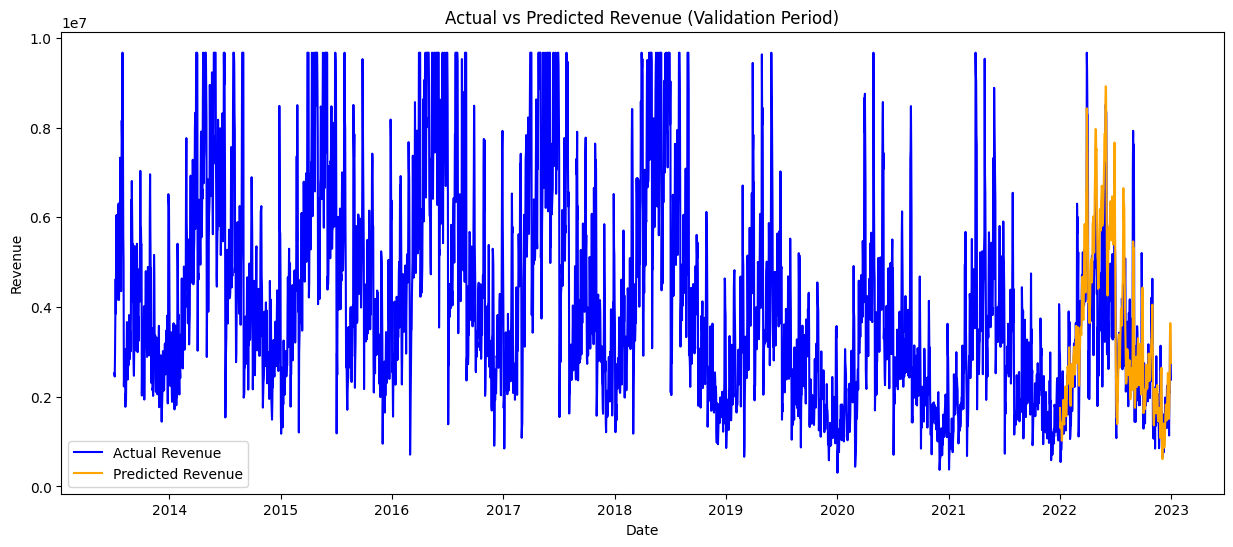

In [20]:
# plot
plt.figure(figsize=(15, 6))
plt.plot(data['Date'], data['Revenue'], label='Actual Revenue', color='blue')
plt.plot(comparison['Date'], comparison['Revenue_pred'], label='Predicted Revenue', color='orange')
plt.title('Actual vs Predicted Revenue (Validation Period)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.show()

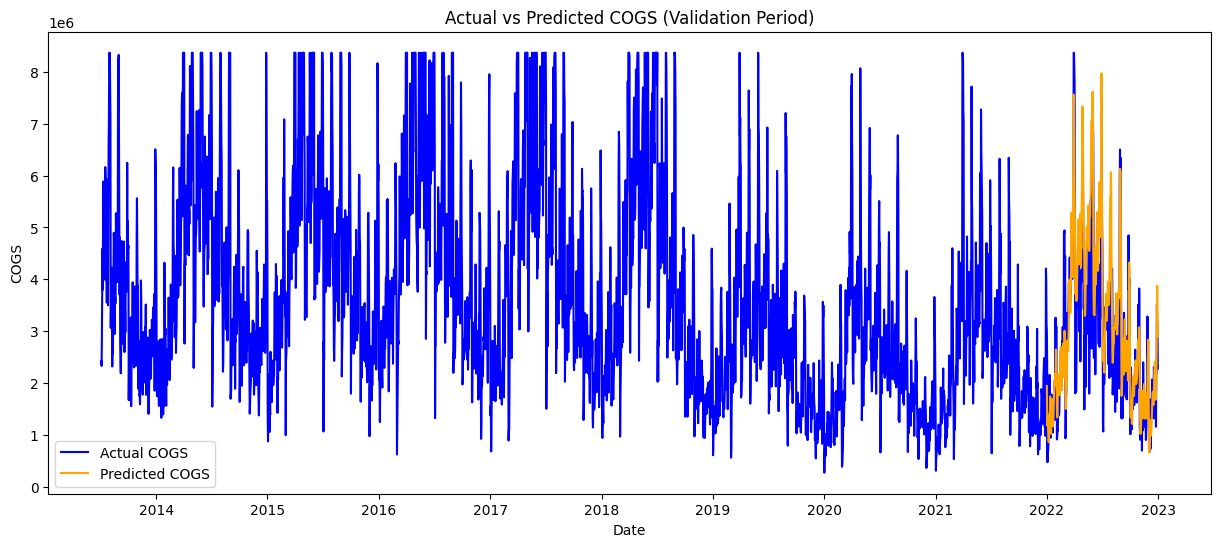

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(data['Date'], data['COGS'], label='Actual COGS', color='blue')
plt.plot(comparison['Date'], comparison['COGS_pred'], label='Predicted COGS', color='orange')
plt.title('Actual vs Predicted COGS (Validation Period)')
plt.xlabel('Date')
plt.ylabel('COGS')
plt.legend()
plt.show()

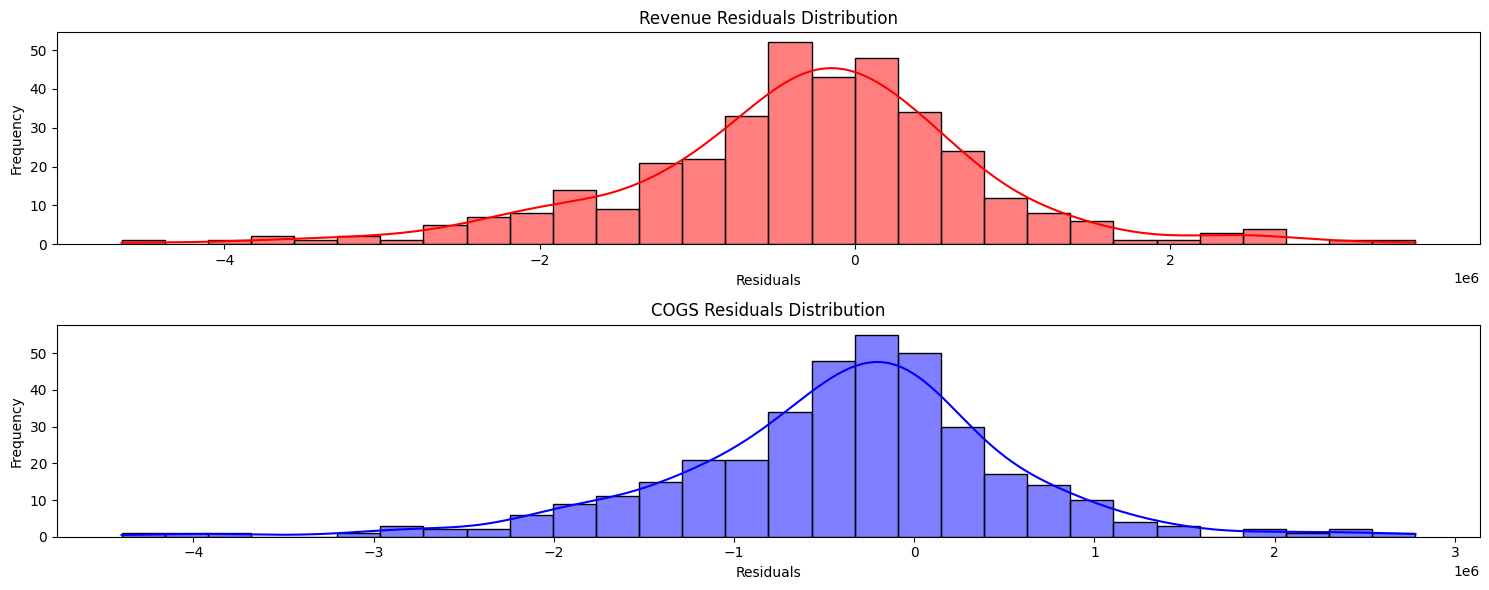

In [22]:
# residuals plot
comparison['Revenue_residual'] = comparison['Revenue_actual'] - comparison['Revenue_pred']
comparison['COGS_residual'] = comparison['COGS_actual'] - comparison['COGS_pred']
plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
sns.histplot(comparison['Revenue_residual'], bins=30, kde=True, color='red')
plt.title('Revenue Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(2, 1, 2)
sns.histplot(comparison['COGS_residual'], bins=30, kde=True, color='blue')
plt.title('COGS Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Top 20 features:
                   feature  importance
35            COGS_lag_365        3828
48      Gross_Margin_lag_1        3758
19           Revenue_lag_2        3731
18           Revenue_lag_1        3687
14   mean_rev_by_dayofweek        3664
36     Revenue_roll_mean_7        3590
24          Revenue_lag_60        3546
21           Revenue_lag_7        3492
33             COGS_lag_60        3480
26         Revenue_lag_365        3431
42        COGS_roll_mean_7        3399
31             COGS_lag_14        3381
27              COGS_lag_1        3343
30              COGS_lag_7        3298
32             COGS_lag_30        3259
25          Revenue_lag_90        3221
17  mean_cogs_by_dayofweek        3203
23          Revenue_lag_30        3202
34             COGS_lag_90        3187
20           Revenue_lag_3        3066


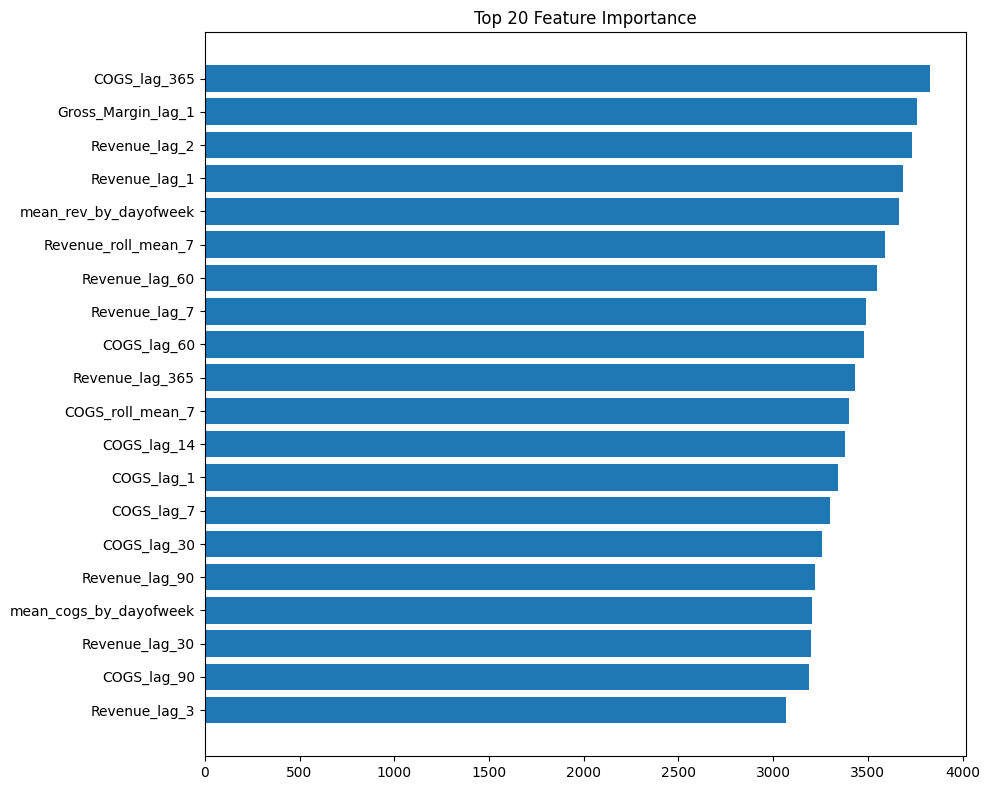

In [23]:
feature_importance = pd.DataFrame({
    'feature': features_for_revenue,
    'importance': model_lgb_rev_final.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features:")
print(feature_importance.head(20))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(20)['feature'][::-1], feature_importance.head(20)['importance'][::-1])
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

Mô hình dựa rất nhiều vào cùng kỳ năm trước.

In [24]:
comparison['dayofweek'] = comparison['Date'].dt.dayofweek
comparison['month'] = comparison['Date'].dt.month
comparison['abs_error'] = abs(comparison['Revenue_actual'] - comparison['Revenue_pred'])

print("MAE (day of week):")
print(comparison.groupby('dayofweek')['abs_error'].mean())

print("\nMAE (month):")
print(comparison.groupby('month')['abs_error'].mean())

MAE (day of week):
dayofweek
0    974452.795924
1    678081.775813
2    822269.565527
3    903754.971112
4    734675.754604
5    813165.926397
6    797021.809865
Name: abs_error, dtype: float64

MAE (month):
month
1     4.522275e+05
2     7.130049e+05
3     6.482177e+05
4     1.145182e+06
5     1.751154e+06
6     1.500611e+06
7     8.162214e+05
8     8.274107e+05
9     6.803471e+05
10    4.088859e+05
11    5.449283e+05
12    3.324948e+05
Name: abs_error, dtype: float64


Doanh thu cuối tuần (thứ 7, CN) thường cao hơn, rồi thứ 2 lao dốc, mô hình không lường trước được mức giảm này.

In [25]:
comparison['Revenue_error'] = comparison['Revenue_actual'] - comparison['Revenue_pred']
comparison['Revenue_error_pct'] = comparison['Revenue_error'] / comparison['Revenue_actual'] * 100
comparison['month'] = comparison['Date'].dt.month
comparison['dayofweek'] = comparison['Date'].dt.dayofweek
comparison['day'] = comparison['Date'].dt.day
comparison['year'] = comparison['Date'].dt.year

worst_days = comparison[abs(comparison['Revenue_error_pct']) > 30].sort_values('Revenue_error_pct')
print(f"Số ngày sai >30%: {len(worst_days)}")
print(worst_days[['Date', 'Revenue_actual', 'Revenue_pred', 'Revenue_error_pct', 'month']].head(20))

Số ngày sai >30%: 123
          Date  Revenue_actual  Revenue_pred  Revenue_error_pct  month
123 2022-05-04      1792730.62  5.095356e+06        -184.223206      5
139 2022-05-20      2226534.20  5.809580e+06        -160.924799      5
61  2022-03-03      1113577.08  2.889917e+06        -159.516582      3
312 2022-11-09       845358.47  2.177330e+06        -157.562897     11
147 2022-05-28      3223975.84  7.875617e+06        -144.282766      5
2   2022-01-03       545563.72  1.298360e+06        -137.985021      1
210 2022-07-30      2682461.47  6.303178e+06        -134.977407      7
159 2022-06-09      2619038.14  5.722519e+06        -118.496965      6
146 2022-05-27      3652675.90  7.678812e+06        -110.224278      5
93  2022-04-04      1974536.55  4.108318e+06        -108.064943      4
33  2022-02-03      1056919.30  2.185225e+06        -106.754198      2
110 2022-04-21      2926459.00  6.024171e+06        -105.851874      4
333 2022-11-30      1317689.52  2.645877e+06        -10

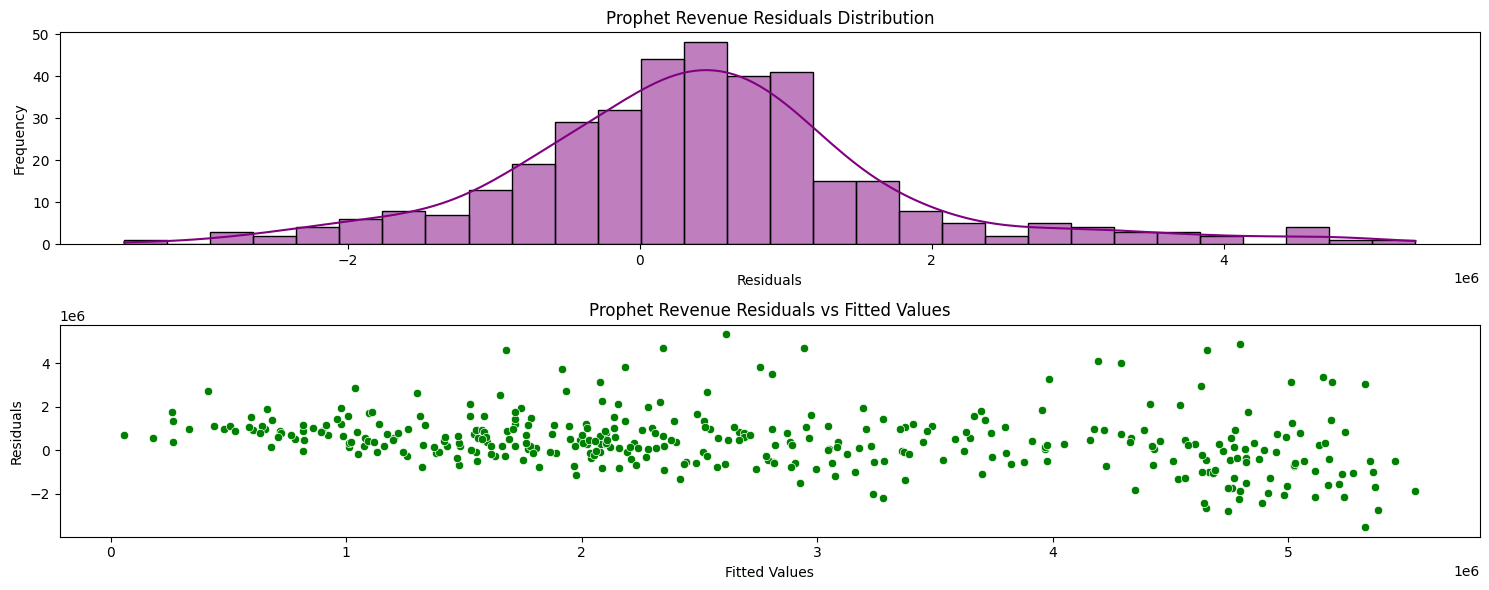

In [26]:
residuals = y_val_revenue - model_prophet_rev.predict(
    pd.DataFrame({'ds': data.loc[val_mask, 'Date']})
)['yhat'].values
plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Prophet Revenue Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.subplot(2, 1, 2)
sns.scatterplot(x=model_prophet_rev.predict(
    pd.DataFrame({'ds': data.loc[val_mask, 'Date']})
)['yhat'].values, y=residuals, color='green')
plt.title('Prophet Revenue Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()